In [1]:
from bhjet import RadiationZone, JetDynamics, BLJet, BHJet
import matplotlib.pyplot as plt
rad = RadiationZone()
jd = JetDynamics()
bljet = BLJet()
bhjet = BHJet()

eV2erg = 1.60218e-12
erg2eV = 1/eV2erg
import numpy as np
e = 4.80320425e-10
c = 2.99792458e10
me = 9.1093897e-28
mp = 1.6726231e-24
mec2 = me * c**2
mpc2 = mp * c**2
h = 6.62e-27
hbar = h/2/np.pi
Bc = me**2 * c**3 / e / hbar
Bcp = mp**2 * c**3 / e / hbar


In [ ]:
rad.B = 15
rad.T_e

In [ ]:
rad.compute_particles()

In [ ]:
bljet.electron_temperature_jet_base

In [ ]:
bljet.compute_jet_dynamics()
bljet.n_zones

In [ ]:
fig, ax = plt.subplots()
ax.loglog(bljet.get_z_center_grid()/bljet.Rg, bljet.get_beta_gamma_grid())

In [2]:
bhjet.init_jet_dynamics(bljet)

In [9]:
nu_out = np.logspace(-6, 12, 300) * eV2erg
bhjet.compute_full_jet(nu_out, index_inj_e=2, frac_nonthermal_e=0.4, theta_obs=0)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99


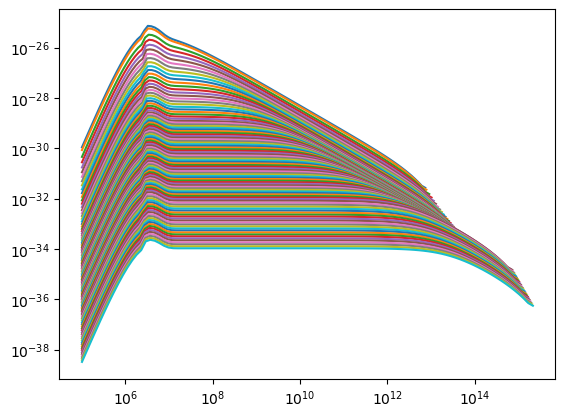

In [5]:
fig, ax = plt.subplots()
for i in range(bljet.n_zones):
    p = bhjet.radiation_zones[i].get_electron_momentum_grid()
    n = bhjet.radiation_zones[i].get_electron_density()
    ax.loglog(p*c * erg2eV, p**2*n)

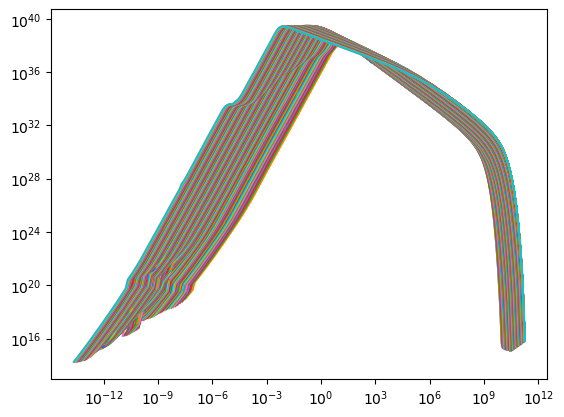

In [6]:
fig, ax = plt.subplots()
for i in range(bljet.n_zones):
    p = bhjet.radiation_zones[i].get_observed_photon_frequency_grid_syn()
    n = bhjet.radiation_zones[i].get_observed_photon_emission_syn()
    # print(p)
    ax.loglog(p*erg2eV, n/p**0)

In [7]:
bhjet.radiation_zones[i].index_inj_e

2.0

In [ ]:
bljet.n_zones=15


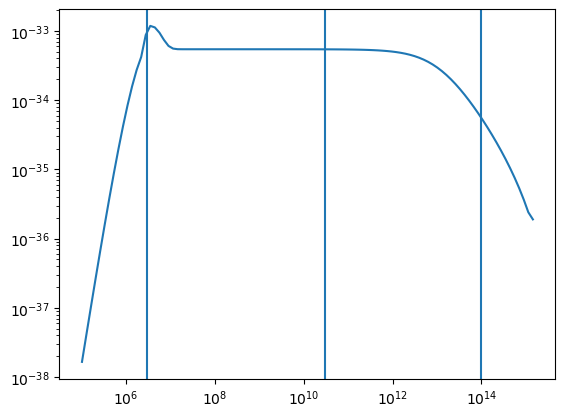

In [7]:
fig, ax = plt.subplots()
i = 90
p = bhjet.radiation_zones[i].get_electron_momentum_grid()
n = bhjet.radiation_zones[i].get_electron_density()
ax.loglog(p*c * erg2eV, p**2*n)
ax.axvline(bhjet.radiation_zones[i].T_e * 1e3 * 3)
ax.axvline(3e10)
ax.axvline(1e14)

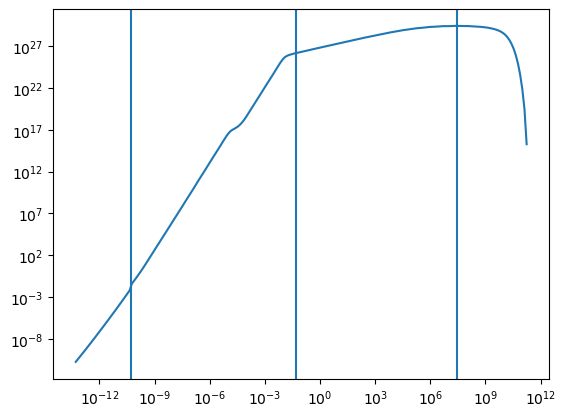

In [8]:
fig, ax = plt.subplots()

p = bhjet.radiation_zones[i].get_observed_photon_frequency_grid_syn()
n = bhjet.radiation_zones[i].get_observed_photon_emission_syn()
ax.loglog(p* erg2eV, n*p**1)
B = bhjet.radiation_zones[i].B
ax.axvline(0.1*(bhjet.radiation_zones[i].T_e * 1e3 * 3/mec2 /erg2eV)**2 * B/Bc * mec2 * erg2eV)
ax.axvline((3e10/mec2 /erg2eV)**2 * B/Bc * mec2 * erg2eV)
ax.axvline(50* (1e14/mec2 /erg2eV)**2 * B/Bc * mec2 * erg2eV)

# ax.loglog(p* erg2eV, p**2*1e65)

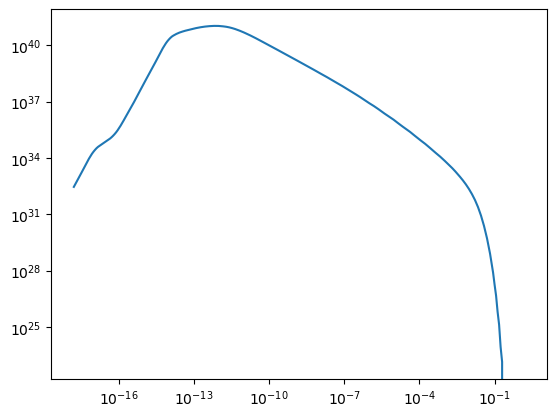

In [10]:
fig, ax = plt.subplots()
# ax.loglog(bhjet.get_photon_energy_obs, bhjet.get_photon_lum_obs())
ax.loglog(nu_out, bhjet.get_photon_lum_obs())